In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report, confusion_matrix

In [3]:
train_dir = "chest_xray/train"
test_dir = "chest_xray/test"
val_dir = "chest_xray/val"

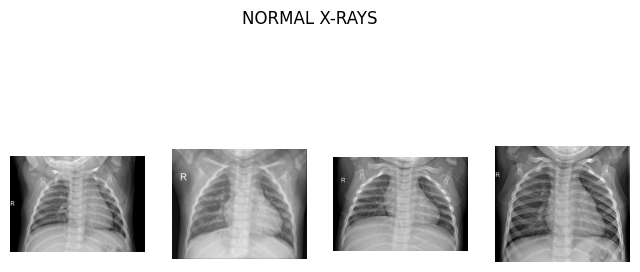

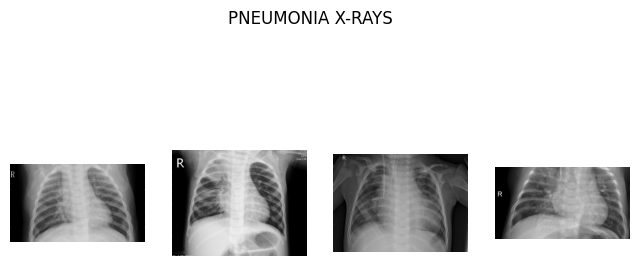

In [4]:
import random
from tensorflow.keras.preprocessing.image import load_img

def show_images(folder, label):
    plt.figure(figsize=(8,4))
    for i in range(4):
        img = load_img(os.path.join(folder, random.choice(os.listdir(folder))))
        plt.subplot(1,4,i+1)
        plt.imshow(img)
        plt.axis("off")
    plt.suptitle(label)
    plt.show()

show_images(train_dir + "/NORMAL", "NORMAL X-RAYS")
show_images(train_dir + "/PNEUMONIA", "PNEUMONIA X-RAYS")

In [5]:
img_size = 224
batch_size = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    zoom_range=0.2,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode="binary"
)

val_data = test_datagen.flow_from_directory(
    val_dir,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode="binary"
)

test_data = test_datagen.flow_from_directory(
    test_dir,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode="binary",
    shuffle=False
)

Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Found 624 images belonging to 2 classes.


In [6]:
base_model = VGG16(weights="imagenet", include_top=False,
                   input_shape=(img_size, img_size, 3))

# Freeze pretrained layers
for layer in base_model.layers:
    layer.trainable = False

model = Sequential([
    base_model,
    Flatten(),
    Dense(128, activation="relu"),
    Dropout(0.5),
    Dense(1, activation="sigmoid")
])

model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 13s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)                   │ (None, 7, 7, 512)           │      14,714,688 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 25088)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │       3,211,392 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 17,926,209 (68.38 MB)

 Trainable params: 3,211,521 (12.25 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [7]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=5
)

C:\Users\Admin\AppData\Roaming\Python\Python312\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 561s 3s/step - accuracy: 0.9122 - loss: 0.2107 - val_accuracy: 0.8125 - val_loss: 0.3974
Epoch 2/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 593s 4s/step - accuracy: 0.9492 - loss: 0.1357 - val_accuracy: 0.8750 - val_loss: 0.2808
Epoch 3/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 607s 4s/step - accuracy: 0.9498 - loss: 0.1259 - val_accuracy: 0.7500 - val_loss: 0.4401
Epoch 4/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 614s 4s/step - accuracy: 0.9578 - loss: 0.1127 - val_accuracy: 0.6875 - val_loss: 0.5500
Epoch 5/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 618s 4s/step - accuracy: 0.9632 - loss: 0.1006 - val_accuracy: 0.8750 - val_loss: 0.2619


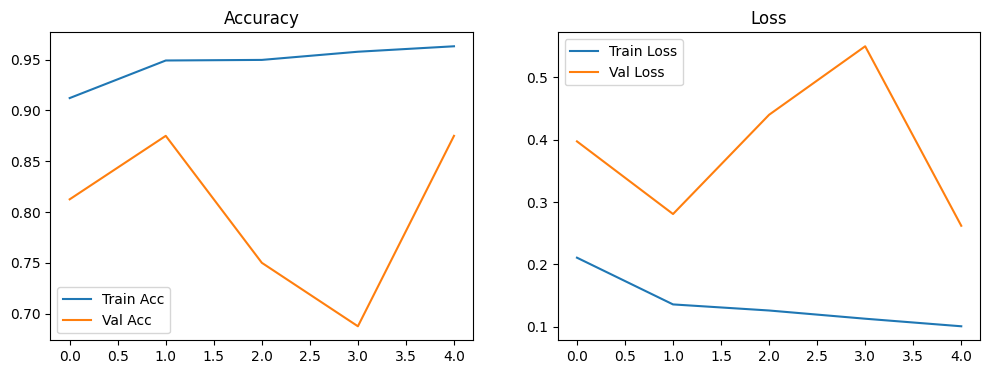

In [8]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history.history["accuracy"], label="Train Acc")
plt.plot(history.history["val_accuracy"], label="Val Acc")
plt.legend()
plt.title("Accuracy")

plt.subplot(1,2,2)
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.legend()
plt.title("Loss")

plt.show()


In [9]:
test_loss, test_acc = model.evaluate(test_data)
print("Test Accuracy:", test_acc)

20/20 ━━━━━━━━━━━━━━━━━━━━ 119s 6s/step - accuracy: 0.9215 - loss: 0.2419
Test Accuracy: 0.9214743375778198


20/20 ━━━━━━━━━━━━━━━━━━━━ 123s 6s/step


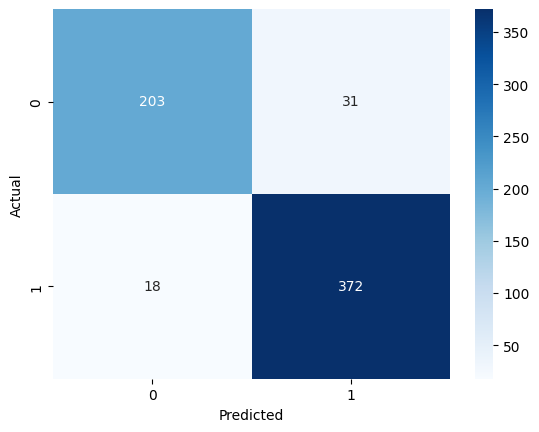

              precision    recall  f1-score   support

           0       0.92      0.87      0.89       234
           1       0.92      0.95      0.94       390

    accuracy                           0.92       624
   macro avg       0.92      0.91      0.92       624
weighted avg       0.92      0.92      0.92       624



In [11]:
predictions = model.predict(test_data)
predictions = (predictions > 0.5).astype(int)

cm = confusion_matrix(test_data.classes, predictions)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print(classification_report(test_data.classes, predictions))

In [12]:
model.save("pneumonia_detection_model.h5")